In [ ]:
!nvidia-smi


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

In [ ]:
from pathlib import Path

print("Kaggle inputs:")

for p in Path("/kaggle/input").iterdir():
    print(p)

In [ ]:
from pathlib import Path

root = Path("/kaggle/input/datasets")

print("Contents of /kaggle/input/datasets:")

for p in root.iterdir():
    print(p)

In [ ]:
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/elakkshayavlsi")

print("Dataset contents:")

for p in DATA_ROOT.iterdir():
    print(p)

In [ ]:
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle")

print("Contents:")

for p in DATA_ROOT.iterdir():
    print(p)

In [ ]:
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle")

gt_dir = DATA_ROOT / "train" / "GT"
noisy_dir = DATA_ROOT / "train" / "NoisyLR"
split_dir = DATA_ROOT / "splits"

gt_files = sorted(gt_dir.glob("*.npy"))
noisy_files = sorted(noisy_dir.glob("*.npy"))

with open(split_dir / "train.txt") as f:
    train_ids = [x.strip() for x in f if x.strip()]

with open(split_dir / "val.txt") as f:
    val_ids = [x.strip() for x in f if x.strip()]

print("GT files:", len(gt_files))
print("NoisyLR files:", len(noisy_files))
print("Train IDs:", len(train_ids))
print("Validation IDs:", len(val_ids))

print("\nFirst GT:", gt_files[0].name)
print("First NoisyLR:", noisy_files[0].name)

print("\nFirst train ID:", train_ids[0])
print("First validation ID:", val_ids[0])

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path


DATA_ROOT = Path(
    "/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle"
)


class KLADataset(Dataset):

    def __init__(self, split_file):

        self.gt_dir = DATA_ROOT / "train" / "GT"
        self.noisy_dir = DATA_ROOT / "train" / "NoisyLR"

        with open(split_file, "r") as f:
            self.ids = [line.strip() for line in f if line.strip()]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, index):

        sample_id = self.ids[index]

        gt = np.load(
            self.gt_dir / f"{sample_id}.npy"
        ).astype(np.float32)

        noisy = np.load(
            self.noisy_dir / f"{sample_id}.npy"
        ).astype(np.float32)

        gt = torch.from_numpy(gt).unsqueeze(0)
        noisy = torch.from_numpy(noisy).unsqueeze(0)

        return noisy, gt

In [ ]:
train_dataset = KLADataset(
    DATA_ROOT / "splits" / "train.txt"
)

val_dataset = KLADataset(
    DATA_ROOT / "splits" / "val.txt"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

In [ ]:
device = torch.device("cuda")

noisy, gt = next(iter(train_loader))

noisy = noisy.to(device, non_blocking=True)
gt = gt.to(device, non_blocking=True)

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))
print("Input:", noisy.shape)
print("Target:", gt.shape)
print("Input dtype:", noisy.dtype)
print("Target dtype:", gt.dtype)
print("Input range:", noisy.min().item(), noisy.max().item())
print("Target range:", gt.min().item(), gt.max().item())

In [ ]:
import torch
import torch.nn as nn


class ResidualBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, x):
        return x + self.block(x)


class BaselineRestoration(nn.Module):

    def __init__(self, channels=64, num_blocks=8):
        super().__init__()

        self.head = nn.Conv2d(1, channels, 3, padding=1)

        self.body = nn.Sequential(
            *[ResidualBlock(channels) for _ in range(num_blocks)]
        )

        self.body_conv = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(channels, channels * 4, 3, padding=1),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.tail = nn.Conv2d(
            channels, 1, 3, padding=1
        )

    def forward(self, x):

        features = self.head(x)
        residual = features

        features = self.body(features)
        features = self.body_conv(features)
        features = features + residual

        features = self.upsample(features)

        return self.tail(features)

In [ ]:
model = BaselineRestoration().to(device)

noisy, gt = next(iter(train_loader))

noisy = noisy.to(device, non_blocking=True)
gt = gt.to(device, non_blocking=True)

with torch.no_grad():
    output = model(noisy)

print("Input :", noisy.shape)
print("Output:", output.shape)

print(
    "Parameters:",
    sum(p.numel() for p in model.parameters())
)

In [ ]:
criterion = nn.L1Loss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4
)

model.train()

optimizer.zero_grad()

output = model(noisy)

loss = criterion(output, gt)

print("Loss:", loss.item())

loss.backward()

optimizer.step()

print("GPU training step completed.")

In [ ]:
import time
import math
import torch
import torch.nn as nn


# -----------------------------
# Configuration
# -----------------------------

EPOCHS = 5
LR = 2e-4

best_val_loss = float("inf")

criterion = nn.L1Loss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)


# -----------------------------
# Training
# -----------------------------

for epoch in range(EPOCHS):

    start_time = time.time()

    model.train()

    train_loss = 0.0

    for batch_idx, (noisy, gt) in enumerate(train_loader):

        noisy = noisy.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        output = model(noisy)

        loss = criterion(output, gt)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(
                f"Epoch {epoch+1}/{EPOCHS} | "
                f"Batch {batch_idx+1}/{len(train_loader)} | "
                f"Loss {loss.item():.5f}"
            )

    train_loss /= len(train_loader)


    # -----------------------------
    # Validation
    # -----------------------------

    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for noisy, gt in val_loader:

            noisy = noisy.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)

            output = model(noisy)

            loss = criterion(output, gt)

            val_loss += loss.item()

    val_loss /= len(val_loader)


    elapsed = time.time() - start_time

    print("\n" + "=" * 60)

    print(
        f"Epoch {epoch+1}/{EPOCHS} completed"
    )

    print(
        f"Train L1: {train_loss:.6f}"
    )

    print(
        f"Val L1:   {val_loss:.6f}"
    )

    print(
        f"Time: {elapsed/60:.2f} minutes"
    )

    print("=" * 60 + "\n")


    # -----------------------------
    # Save best model
    # -----------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
            },
            "/kaggle/working/baseline_best.pth"
        )

        print(
            f"✓ Best model saved. Val L1: {val_loss:.6f}"
        )

In [ ]:
import torch
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# Load best checkpoint
checkpoint = torch.load(
    "/kaggle/working/baseline_best.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded checkpoint from epoch:", checkpoint["epoch"])
print("Best validation L1:", checkpoint["val_loss"])

In [ ]:
psnr_values = []
ssim_values = []

with torch.no_grad():

    for noisy, gt in val_loader:

        noisy = noisy.to(device, non_blocking=True)

        output = model(noisy)

        output = output.cpu().numpy()
        gt = gt.numpy()

        for i in range(output.shape[0]):

            pred = output[i, 0]
            target = gt[i, 0]

            # Output may temporarily go outside [0,1].
            # Evaluation is performed against the valid GT range.
            pred = np.clip(pred, 0.0, 1.0)

            psnr = peak_signal_noise_ratio(
                target,
                pred,
                data_range=1.0
            )

            ssim = structural_similarity(
                target,
                pred,
                data_range=1.0
            )

            psnr_values.append(psnr)
            ssim_values.append(ssim)

print("Validation PSNR:", np.mean(psnr_values))
print("Validation SSIM:", np.mean(ssim_values))

In [ ]:
import matplotlib.pyplot as plt

model.eval()

noisy, gt = next(iter(val_loader))

noisy_gpu = noisy.to(device)

with torch.no_grad():
    restored = model(noisy_gpu)

restored = restored.cpu()

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):

    # NoisyLR
    axes[0, i].imshow(
        noisy[i, 0].numpy(),
        cmap="gray"
    )
    axes[0, i].set_title("NoisyLR")
    axes[0, i].axis("off")

    # Restored
    axes[1, i].imshow(
        restored[i, 0].numpy(),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[1, i].set_title("Restored")
    axes[1, i].axis("off")

    # Ground truth
    axes[2, i].imshow(
        gt[i, 0].numpy(),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[2, i].set_title("Ground Truth")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch

checkpoint = torch.load(
    "/kaggle/working/baseline_best.pth",
    map_location="cpu"
)

print("Checkpoint loaded successfully")
print("Epoch:", checkpoint["epoch"])
print("Validation L1:", checkpoint["val_loss"])
print("Number of tensors:", len(checkpoint["model_state_dict"]))

In [ ]:
from pathlib import Path

path = Path("/kaggle/working/baseline_best.pth")

print("Exists:", path.exists())

if path.exists():
    print("File:", path)
    print("Size:", path.stat().st_size / (1024 * 1024), "MB")

In [ ]:
import torch
import torch.nn.functional as F


def gradient_loss(pred, target):
    pred_x = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    pred_y = pred[:, :, 1:, :] - pred[:, :, :-1, :]

    target_x = target[:, :, :, 1:] - target[:, :, :, :-1]
    target_y = target[:, :, 1:, :] - target[:, :, :-1, :]

    loss_x = F.l1_loss(pred_x, target_x)
    loss_y = F.l1_loss(pred_y, target_y)

    return loss_x + loss_y


def charbonnier_loss(pred, target, eps=1e-3):
    diff = pred - target
    return torch.mean(torch.sqrt(diff * diff + eps * eps))


def v2_loss(pred, target):
    l_char = charbonnier_loss(pred, target)
    l_grad = gradient_loss(pred, target)

    return l_char + 0.1 * l_grad

In [ ]:
import torch

# Start from the verified V1 model
model_v2 = BaselineRestoration().to(device)

checkpoint = torch.load(
    "/kaggle/working/baseline_best.pth",
    map_location=device
)

model_v2.load_state_dict(checkpoint["model_state_dict"])

optimizer_v2 = torch.optim.AdamW(
    model_v2.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scaler = torch.amp.GradScaler("cuda")

EPOCHS_V2 = 5
best_val_v2 = float("inf")

for epoch in range(EPOCHS_V2):

    model_v2.train()
    train_loss = 0.0

    for batch_idx, (noisy, gt) in enumerate(train_loader):

        noisy = noisy.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        optimizer_v2.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):
            output = model_v2(noisy)
            loss = v2_loss(output, gt)

        scaler.scale(loss).backward()
        scaler.step(optimizer_v2)
        scaler.update()

        train_loss += loss.item()

        if (batch_idx + 1) % 100 == 0:
            print(
                f"Epoch {epoch+1}/{EPOCHS_V2} | "
                f"Batch {batch_idx+1}/{len(train_loader)} | "
                f"Loss {loss.item():.5f}"
            )

    train_loss /= len(train_loader)

    # Validation
    model_v2.eval()
    val_loss = 0.0

    with torch.no_grad():

        for noisy, gt in val_loader:

            noisy = noisy.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):
                output = model_v2(noisy)
                loss = v2_loss(output, gt)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(
        f"\nEpoch {epoch+1}/{EPOCHS_V2} | "
        f"Train: {train_loss:.6f} | "
        f"Val: {val_loss:.6f}"
    )

    if val_loss < best_val_v2:

        best_val_v2 = val_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model_v2.state_dict(),
                "optimizer_state_dict": optimizer_v2.state_dict(),
                "val_loss": val_loss,
            },
            "/kaggle/working/v2_best.pth"
        )

        print("✓ V2 checkpoint saved")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ChannelAttention(nn.Module):

    def __init__(self, channels, reduction=8):
        super().__init__()

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        attention = self.fc(self.pool(x))
        return x * attention


class AttentionResidualBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()

        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)

        self.act = nn.GELU()

        self.attention = ChannelAttention(channels)

    def forward(self, x):

        residual = x

        x = self.conv1(x)
        x = self.act(x)

        x = self.conv2(x)

        x = self.attention(x)

        return x + residual


class V3Restoration(nn.Module):

    def __init__(self, channels=64, num_blocks=8):
        super().__init__()

        self.head = nn.Conv2d(
            1, channels, 3, padding=1
        )

        self.blocks = nn.Sequential(
            *[
                AttentionResidualBlock(channels)
                for _ in range(num_blocks)
            ]
        )

        self.body = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.GELU()
        )

        self.tail = nn.Conv2d(
            channels, 1, 3, padding=1
        )

    def forward(self, x):

        features = self.head(x)

        residual = features

        features = self.blocks(features)

        features = self.body(features)

        features = features + residual

        features = self.upsample(features)

        return self.tail(features)

In [ ]:
model_v3 = V3Restoration().to(device)

parameters = sum(
    p.numel()
    for p in model_v3.parameters()
)

print("Parameters:", parameters)

test_input = torch.randn(
    2, 1, 128, 128,
    device=device
)

with torch.no_grad():
    test_output = model_v3(test_input)

print("Input :", test_input.shape)
print("Output:", test_output.shape)

In [ ]:
model_v3.train()

optimizer_v3 = torch.optim.AdamW(
    model_v3.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

criterion_v3 = nn.L1Loss()

noisy, gt = next(iter(train_loader))

noisy = noisy.to(device, non_blocking=True)
gt = gt.to(device, non_blocking=True)

optimizer_v3.zero_grad(set_to_none=True)

output = model_v3(noisy)

loss = criterion_v3(output, gt)

print("Loss:", loss.item())

loss.backward()

optimizer_v3.step()

print("V3 training step completed.")

In [ ]:
import time
import torch

EPOCHS_V3 = 5
LR_V3 = 2e-4

optimizer_v3 = torch.optim.AdamW(
    model_v3.parameters(),
    lr=LR_V3,
    weight_decay=1e-4
)

criterion_v3 = nn.L1Loss()

best_val_v3 = float("inf")

for epoch in range(EPOCHS_V3):

    start = time.time()

    model_v3.train()
    train_loss = 0.0

    for batch_idx, (noisy, gt) in enumerate(train_loader):

        noisy = noisy.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        optimizer_v3.zero_grad(set_to_none=True)

        output = model_v3(noisy)

        loss = criterion_v3(output, gt)

        loss.backward()
        optimizer_v3.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model_v3.eval()
    val_loss = 0.0

    with torch.no_grad():

        for noisy, gt in val_loader:

            noisy = noisy.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)

            output = model_v3(noisy)

            loss = criterion_v3(output, gt)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    elapsed = (time.time() - start) / 60

    print(
        f"Epoch {epoch+1}/5 | "
        f"Train L1: {train_loss:.6f} | "
        f"Val L1: {val_loss:.6f} | "
        f"Time: {elapsed:.2f} min"
    )

    if val_loss < best_val_v3:

        best_val_v3 = val_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model_v3.state_dict(),
                "optimizer_state_dict": optimizer_v3.state_dict(),
                "val_loss": val_loss,
            },
            "/kaggle/working/v3_best.pth"
        )

        print("✓ V3 checkpoint saved")

In [ ]:
model_v1 = BaselineRestoration().to(device)

checkpoint = torch.load(
    "/kaggle/working/baseline_best.pth",
    map_location=device
)

model_v1.load_state_dict(checkpoint["model_state_dict"])

optimizer_v1 = torch.optim.AdamW(
    model_v1.parameters(),
    lr=5e-5,
    weight_decay=1e-4
)

criterion_v1 = nn.L1Loss()

best_val = checkpoint["val_loss"]

print("Starting from Val L1:", best_val)

In [ ]:
EPOCHS = 5
best_val = 0.03241522014141083

for epoch in range(EPOCHS):

    model_v1.train()
    train_loss = 0.0

    for noisy, gt in train_loader:

        noisy = noisy.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        optimizer_v1.zero_grad(set_to_none=True)

        output = model_v1(noisy)

        loss = criterion_v1(output, gt)

        loss.backward()
        optimizer_v1.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model_v1.eval()
    val_loss = 0.0

    with torch.no_grad():

        for noisy, gt in val_loader:

            noisy = noisy.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)

            output = model_v1(noisy)

            loss = criterion_v1(output, gt)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train L1: {train_loss:.6f} | "
        f"Val L1: {val_loss:.6f}"
    )

    if val_loss < best_val:

        best_val = val_loss

        torch.save(
            {
                "epoch": epoch + 6,
                "model_state_dict": model_v1.state_dict(),
                "optimizer_state_dict": optimizer_v1.state_dict(),
                "val_loss": val_loss,
            },
            "/kaggle/working/v1_extended_best.pth"
        )

        print("✓ New best checkpoint saved")

In [ ]:
import torch
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

checkpoint = torch.load(
    "/kaggle/working/v1_extended_best.pth",
    map_location=device
)

model_v1.load_state_dict(checkpoint["model_state_dict"])
model_v1.eval()

psnr_values = []
ssim_values = []

with torch.no_grad():

    for noisy, gt in val_loader:

        noisy = noisy.to(device, non_blocking=True)

        output = model_v1(noisy)

        output = output.cpu().numpy()
        gt = gt.numpy()

        for i in range(output.shape[0]):

            pred = np.clip(output[i, 0], 0.0, 1.0)
            target = gt[i, 0]

            psnr_values.append(
                peak_signal_noise_ratio(
                    target,
                    pred,
                    data_range=1.0
                )
            )

            ssim_values.append(
                structural_similarity(
                    target,
                    pred,
                    data_range=1.0
                )
            )

print("Best epoch:", checkpoint["epoch"])
print("Best Val L1:", checkpoint["val_loss"])
print("PSNR:", np.mean(psnr_values))
print("SSIM:", np.mean(ssim_values))

In [ ]:
!pip -q install lpips

In [ ]:
import lpips
import torch
import numpy as np

loss_fn = lpips.LPIPS(net='alex').to(device)
loss_fn.eval()

checkpoint = torch.load(
    "/kaggle/working/v1_extended_best.pth",
    map_location=device
)

model_v1.load_state_dict(checkpoint["model_state_dict"])
model_v1.eval()

lpips_values = []

with torch.no_grad():

    for noisy, gt in val_loader:

        noisy = noisy.to(device)
        gt = gt.to(device)

        pred = model_v1(noisy)

        pred = torch.clamp(pred, 0, 1)
        gt = torch.clamp(gt, 0, 1)

        # LPIPS expects 3-channel images in [-1, 1]
        pred_3 = pred.repeat(1, 3, 1, 1) * 2 - 1
        gt_3 = gt.repeat(1, 3, 1, 1) * 2 - 1

        score = loss_fn(pred_3, gt_3)

        lpips_values.extend(
            score.flatten().cpu().numpy()
        )

print("LPIPS:", np.mean(lpips_values))

In [4]:
import torch
from pathlib import Path

print(
    "Checkpoint exists:",
    Path("/kaggle/working/v1_extended_best.pth").exists()
)

Checkpoint exists: False


In [5]:
from pathlib import Path

for p in Path("/kaggle/input").rglob("*"):
    if p.is_file():
        print(p)

/kaggle/input/datasets/elakkshayavlsi/checkpoint/v1_extended_best.pth
/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/splits/val.txt
/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/splits/train.txt
/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/train/GT/001314.npy
/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/train/GT/002909.npy
/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/train/GT/000983.npy
/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/train/GT/002724.npy
/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/train/GT/001467.npy
/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/train/GT/001659.npy
/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/train/GT/000708.npy
/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/train/GT/001918.npy
/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/train/GT/002097.npy
/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/train/GT/001194.npy
/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/train/GT/

In [6]:
import torch
import os

ckpt_path = "/kaggle/input/datasets/elakkshayavlsi/checkpoint/v1_extended_best.pth"

print("Exists:", os.path.exists(ckpt_path))
print("Size:", os.path.getsize(ckpt_path) / (1024**2), "MB")

checkpoint = torch.load(ckpt_path, map_location="cpu")

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCheckpoint keys:")
    for k in checkpoint.keys():
        print(" -", k)

Exists: True
Size: 8.936848640441895 MB
Checkpoint type: <class 'dict'>

Checkpoint keys:
 - epoch
 - model_state_dict
 - optimizer_state_dict
 - val_loss


In [7]:
print("Epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])

model_state = checkpoint["model_state_dict"]

print("\nNumber of model parameters stored:", len(model_state))

print("\nFirst 15 weight keys:")
for i, key in enumerate(model_state.keys()):
    if i >= 15:
        break
    print(key, model_state[key].shape)

Epoch: 10
Validation loss: 0.03154092188924551

Number of model parameters stored: 40

First 15 weight keys:
head.weight torch.Size([64, 1, 3, 3])
head.bias torch.Size([64])
body.0.block.0.weight torch.Size([64, 64, 3, 3])
body.0.block.0.bias torch.Size([64])
body.0.block.2.weight torch.Size([64, 64, 3, 3])
body.0.block.2.bias torch.Size([64])
body.1.block.0.weight torch.Size([64, 64, 3, 3])
body.1.block.0.bias torch.Size([64])
body.1.block.2.weight torch.Size([64, 64, 3, 3])
body.1.block.2.bias torch.Size([64])
body.2.block.0.weight torch.Size([64, 64, 3, 3])
body.2.block.0.bias torch.Size([64])
body.2.block.2.weight torch.Size([64, 64, 3, 3])
body.2.block.2.bias torch.Size([64])
body.3.block.0.weight torch.Size([64, 64, 3, 3])


In [9]:
model_v1 = BaselineRestoration().to(device)

model_v1.load_state_dict(
    checkpoint["model_state_dict"]
)

model_v1.eval()

print("✓ Best V1 checkpoint loaded")
print("Device:", device)
print("Parameters:", sum(p.numel() for p in model_v1.parameters()))

NameError: name 'BaselineRestoration' is not defined

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, x):
        return x + self.block(x)


class BaselineRestoration(nn.Module):

    def __init__(self, channels=64, num_blocks=4):
        super().__init__()

        self.head = nn.Conv2d(
            1, channels, 3, padding=1
        )

        self.body = nn.Sequential(
            *[
                ResidualBlock(channels)
                for _ in range(num_blocks)
            ]
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.tail = nn.Conv2d(
            channels, 1, 3, padding=1
        )

    def forward(self, x):

        x = self.head(x)
        x = self.body(x)
        x = self.upsample(x)
        x = self.tail(x)

        return x

In [12]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [14]:
model_v1 = BaselineRestoration().to(device)

model_v1.load_state_dict(
    checkpoint["model_state_dict"]
)

model_v1.eval()

print("✓ Best V1 checkpoint loaded")
print("Device:", device)
print(
    "Parameters:",
    sum(p.numel() for p in model_v1.parameters())
)

RuntimeError: Error(s) in loading state_dict for BaselineRestoration:
	Unexpected key(s) in state_dict: "body_conv.weight", "body_conv.bias", "body.4.block.0.weight", "body.4.block.0.bias", "body.4.block.2.weight", "body.4.block.2.bias", "body.5.block.0.weight", "body.5.block.0.bias", "body.5.block.2.weight", "body.5.block.2.bias", "body.6.block.0.weight", "body.6.block.0.bias", "body.6.block.2.weight", "body.6.block.2.bias", "body.7.block.0.weight", "body.7.block.0.bias", "body.7.block.2.weight", "body.7.block.2.bias". 

In [15]:
import torch
import torch.nn as nn


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, x):
        return x + self.block(x)


class BaselineRestoration(nn.Module):
    def __init__(self, channels=64, num_blocks=8):
        super().__init__()

        self.head = nn.Conv2d(
            1, channels, 3, padding=1
        )

        self.body = nn.Sequential(
            *[
                ResidualBlock(channels)
                for _ in range(num_blocks)
            ]
        )

        self.body_conv = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.tail = nn.Conv2d(
            channels, 1, 3, padding=1
        )

    def forward(self, x):

        x = self.head(x)

        residual = x
        x = self.body(x)
        x = self.body_conv(x)
        x = x + residual

        x = self.upsample(x)
        x = self.tail(x)

        return x

In [16]:
model_v1 = BaselineRestoration().to(device)

model_v1.load_state_dict(
    checkpoint["model_state_dict"]
)

model_v1.eval()

print("✓ Best V1 checkpoint loaded")
print("Device:", device)
print(
    "Parameters:",
    sum(p.numel() for p in model_v1.parameters())
)

✓ Best V1 checkpoint loaded
Device: cuda
Parameters: 776705


In [17]:
import torch
import torch.nn as nn


class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, x):
        return x + self.block(x)


class BaselineRestoration(nn.Module):
    def __init__(self, channels=64, num_blocks=8):
        super().__init__()

        self.head = nn.Conv2d(
            1, channels, 3, padding=1
        )

        self.body = nn.Sequential(
            *[
                ResidualBlock(channels)
                for _ in range(num_blocks)
            ]
        )

        self.body_conv = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.tail = nn.Conv2d(
            channels, 1, 3, padding=1
        )

    def forward(self, x):
        x = self.head(x)

        residual = x

        x = self.body(x)
        x = self.body_conv(x)

        x = x + residual

        x = self.upsample(x)
        x = self.tail(x)

        return x

In [18]:
model_v1 = BaselineRestoration().to(device)

print(
    "Parameters:",
    sum(p.numel() for p in model_v1.parameters())
)

Parameters: 776705


In [19]:
model_v1.load_state_dict(
    checkpoint["model_state_dict"]
)

model_v1.eval()

print("✓ Best V1 checkpoint loaded")
print("Device:", device)
print("Parameters:", sum(p.numel() for p in model_v1.parameters()))

✓ Best V1 checkpoint loaded
Device: cuda
Parameters: 776705


In [20]:
noisy, gt = next(iter(val_loader))

noisy = noisy.to(device)

with torch.no_grad():
    output = model_v1(noisy)

print("Input :", noisy.shape)
print("Output:", output.shape)
print("Target:", gt.shape)

NameError: name 'val_loader' is not defined

In [21]:
from pathlib import Path

DATA_ROOT = Path(
    "/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle"
)

print("Dataset root:", DATA_ROOT)
print("Exists:", DATA_ROOT.exists())

print("\nContents:")
for p in DATA_ROOT.iterdir():
    print(p)

Dataset root: /kaggle/input/datasets/elakkshayavlsi/semicon/kaggle
Exists: True

Contents:
/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/splits
/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/train


In [22]:
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch

DATA_ROOT = Path(
    "/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle"
)

TRAIN_DIR = DATA_ROOT / "train"
GT_DIR = TRAIN_DIR / "GT"
NOISY_DIR = TRAIN_DIR / "NoisyLR"

TRAIN_TXT = DATA_ROOT / "splits" / "train.txt"
VAL_TXT = DATA_ROOT / "splits" / "val.txt"


class SemiconductorDataset(Dataset):

    def __init__(self, ids_file):
        with open(ids_file, "r") as f:
            self.ids = [line.strip() for line in f if line.strip()]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):

        sample_id = self.ids[idx]

        noisy = np.load(
            NOISY_DIR / f"{sample_id}.npy"
        ).astype(np.float32)

        gt = np.load(
            GT_DIR / f"{sample_id}.npy"
        ).astype(np.float32)

        noisy = torch.from_numpy(noisy)
        gt = torch.from_numpy(gt)

        # Ensure [C,H,W]
        if noisy.ndim == 2:
            noisy = noisy.unsqueeze(0)

        if gt.ndim == 2:
            gt = gt.unsqueeze(0)

        return noisy, gt


train_dataset = SemiconductorDataset(TRAIN_TXT)
val_dataset = SemiconductorDataset(VAL_TXT)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

noisy, gt = next(iter(val_loader))

print("Validation input :", noisy.shape)
print("Validation target:", gt.shape)

Train samples: 2880
Validation samples: 320
Validation input : torch.Size([8, 1, 128, 128])
Validation target: torch.Size([8, 1, 256, 256])


In [23]:
model_v1.eval()

noisy, gt = next(iter(val_loader))

noisy = noisy.to(device)

with torch.no_grad():
    output = model_v1(noisy)

print("Input :", noisy.shape)
print("Output:", output.shape)
print("Target:", gt.shape)

print("Output range:", output.min().item(), output.max().item())

Input : torch.Size([8, 1, 128, 128])
Output: torch.Size([8, 1, 256, 256])
Target: torch.Size([8, 1, 256, 256])
Output range: -0.018747063353657722 1.1256115436553955


In [24]:
from pathlib import Path

root = Path("/kaggle/input/datasets/elakkshayavlsi/semicon/kaggle")

print("All folders/files:")
for p in root.rglob("*"):
    if p.is_dir():
        print("[DIR] ", p)

All folders/files:
[DIR]  /kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/splits
[DIR]  /kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/train
[DIR]  /kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/train/GT
[DIR]  /kaggle/input/datasets/elakkshayavlsi/semicon/kaggle/train/NoisyLR


In [25]:
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/val_predictions")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Output directory:", OUTPUT_DIR)
print("Ready to generate validation predictions.")

Output directory: /kaggle/working/val_predictions
Ready to generate validation predictions.


In [26]:
import numpy as np
from pathlib import Path
import torch

model_v1.eval()

OUTPUT_DIR = Path("/kaggle/working/val_predictions")
OUTPUT_DIR.mkdir(exist_ok=True)

count = 0

with torch.no_grad():

    for noisy, gt in val_loader:

        noisy = noisy.to(device, non_blocking=True)

        output = model_v1(noisy)

        output = torch.clamp(output, 0.0, 1.0)

        output = output.cpu().numpy()

        for i in range(output.shape[0]):

            sample_id = val_dataset.ids[count]

            np.save(
                OUTPUT_DIR / f"{sample_id}.npy",
                output[i, 0].astype(np.float32)
            )

            count += 1

print("Predictions generated:", count)
print("Output directory:", OUTPUT_DIR)

Predictions generated: 320
Output directory: /kaggle/working/val_predictions


In [27]:
import numpy as np
from pathlib import Path
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

pred_dir = Path("/kaggle/working/val_predictions")

psnr_values = []
ssim_values = []

for sample_id in val_dataset.ids:

    pred = np.load(pred_dir / f"{sample_id}.npy")
    target = np.load(GT_DIR / f"{sample_id}.npy")

    pred = np.clip(pred, 0.0, 1.0).astype(np.float32)
    target = np.clip(target, 0.0, 1.0).astype(np.float32)

    psnr_values.append(
        peak_signal_noise_ratio(
            target,
            pred,
            data_range=1.0
        )
    )

    ssim_values.append(
        structural_similarity(
            target,
            pred,
            data_range=1.0
        )
    )

print("Predictions checked:", len(psnr_values))
print("Mean PSNR:", np.mean(psnr_values))
print("Mean SSIM:", np.mean(ssim_values))
print("Min PSNR:", np.min(psnr_values))
print("Max PSNR:", np.max(psnr_values))

Predictions checked: 320
Mean PSNR: 28.126673288592496
Mean SSIM: 0.7562002024869916
Min PSNR: 11.06102995274542
Max PSNR: 41.73851673440328


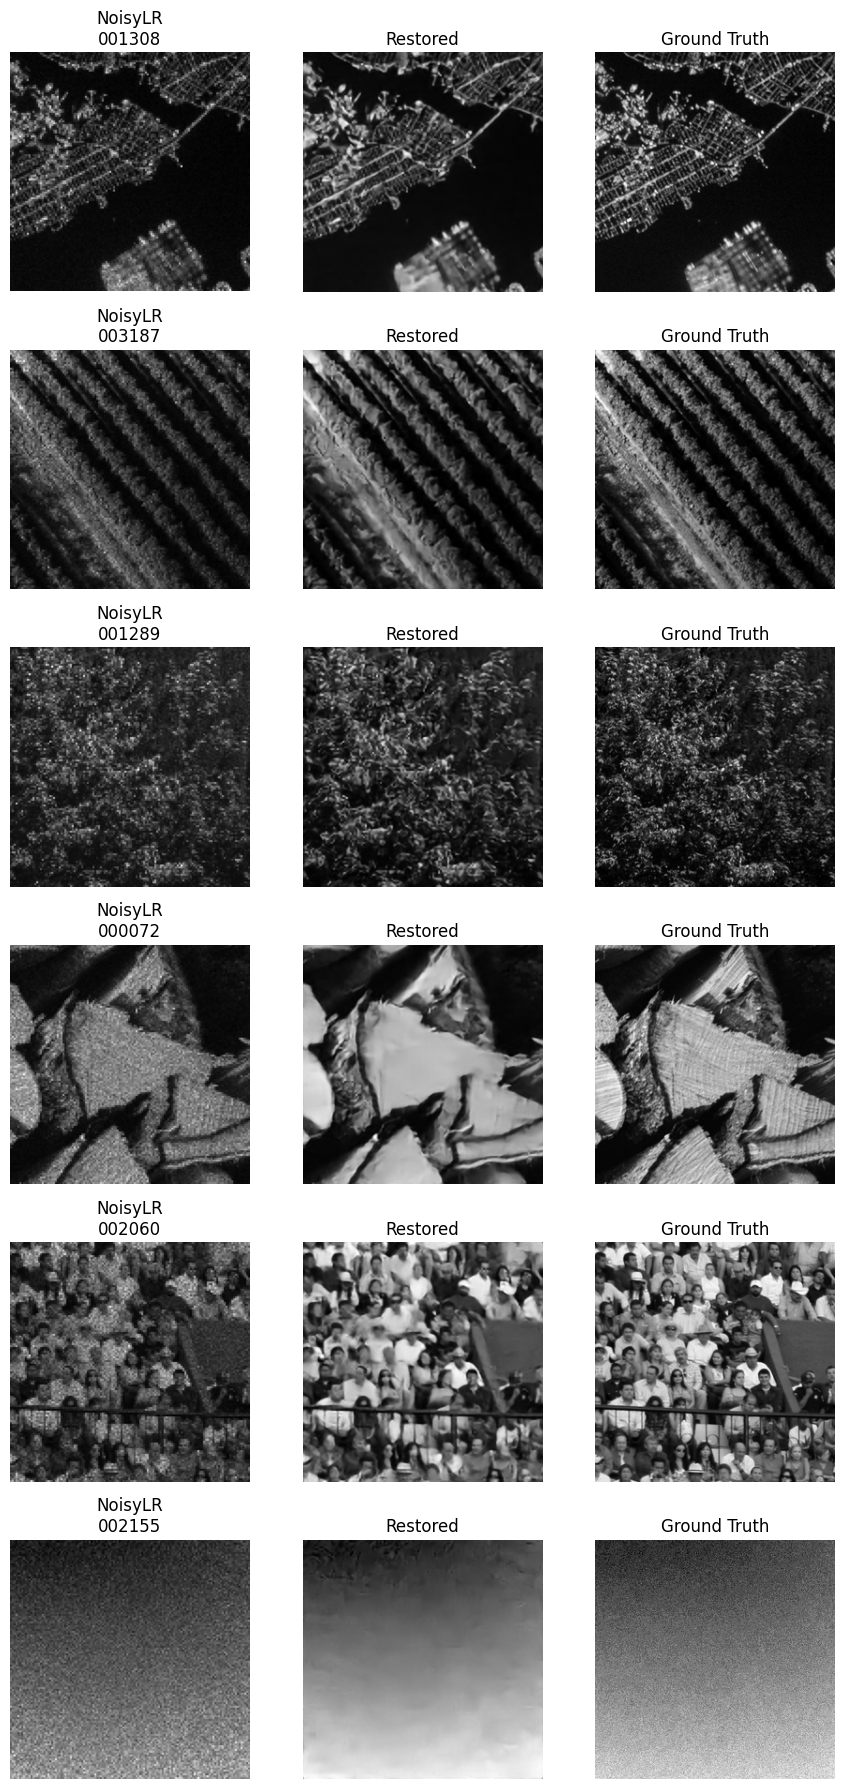

Saved: /kaggle/working/validation_comparison.png


In [28]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Pick first 6 validation samples
sample_ids = val_dataset.ids[:6]

fig, axes = plt.subplots(
    6, 3,
    figsize=(9, 18)
)

for row, sample_id in enumerate(sample_ids):

    noisy = np.load(
        NOISY_DIR / f"{sample_id}.npy"
    )

    pred = np.load(
        pred_dir / f"{sample_id}.npy"
    )

    gt = np.load(
        GT_DIR / f"{sample_id}.npy"
    )

    axes[row, 0].imshow(noisy, cmap="gray")
    axes[row, 0].set_title(f"NoisyLR\n{sample_id}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        np.clip(pred, 0, 1),
        cmap="gray"
    )
    axes[row, 1].set_title("Restored")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(
        np.clip(gt, 0, 1),
        cmap="gray"
    )
    axes[row, 2].set_title("Ground Truth")
    axes[row, 2].axis("off")

plt.tight_layout()

comparison_path = "/kaggle/working/validation_comparison.png"
plt.savefig(comparison_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", comparison_path)

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class V4ResidualRestoration(nn.Module):

    def __init__(self, channels=64, num_blocks=8):
        super().__init__()

        self.head = nn.Conv2d(
            1, channels, 3, padding=1
        )

        self.body = nn.Sequential(
            *[
                ResidualBlock(channels)
                for _ in range(num_blocks)
            ]
        )

        self.body_conv = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.tail = nn.Conv2d(
            channels, 1, 3, padding=1
        )

    def forward(self, x):

        # Bicubic baseline
        base = F.interpolate(
            x,
            scale_factor=2,
            mode="bicubic",
            align_corners=False
        )

        features = self.head(x)

        residual = features

        features = self.body(features)
        features = self.body_conv(features)
        features = features + residual

        correction = self.upsample(features)
        correction = self.tail(correction)

        return base + correction

In [30]:
model_v4 = V4ResidualRestoration().to(device)

test_input = torch.randn(
    2, 1, 128, 128,
    device=device
)

with torch.no_grad():
    test_output = model_v4(test_input)

print("Parameters:",
      sum(p.numel() for p in model_v4.parameters()))

print("Input :", test_input.shape)
print("Output:", test_output.shape)

Parameters: 776705
Input : torch.Size([2, 1, 128, 128])
Output: torch.Size([2, 1, 256, 256])


In [31]:
criterion_v4 = nn.L1Loss()

optimizer_v4 = torch.optim.AdamW(
    model_v4.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

model_v4.train()

noisy, gt = next(iter(train_loader))

noisy = noisy.to(device)
gt = gt.to(device)

optimizer_v4.zero_grad(set_to_none=True)

output = model_v4(noisy)

loss = criterion_v4(output, gt)

print("Loss before backward:", loss.item())

loss.backward()
optimizer_v4.step()

print("V4 training step completed.")

Loss before backward: 0.08167951554059982
V4 training step completed.


In [32]:
import time

EPOCHS_V4 = 5
best_val_v4 = float("inf")

# Reinitialize optimizer because the previous step was only a test
optimizer_v4 = torch.optim.AdamW(
    model_v4.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

for epoch in range(EPOCHS_V4):

    start = time.time()

    model_v4.train()
    train_loss = 0.0

    for noisy, gt in train_loader:

        noisy = noisy.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        optimizer_v4.zero_grad(set_to_none=True)

        output = model_v4(noisy)

        loss = criterion_v4(output, gt)

        loss.backward()
        optimizer_v4.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model_v4.eval()
    val_loss = 0.0

    with torch.no_grad():

        for noisy, gt in val_loader:

            noisy = noisy.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)

            output = model_v4(noisy)

            loss = criterion_v4(output, gt)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    elapsed = (time.time() - start) / 60

    print(
        f"Epoch {epoch+1}/5 | "
        f"Train L1: {train_loss:.6f} | "
        f"Val L1: {val_loss:.6f} | "
        f"Time: {elapsed:.2f} min"
    )

    if val_loss < best_val_v4:

        best_val_v4 = val_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model_v4.state_dict(),
                "optimizer_state_dict": optimizer_v4.state_dict(),
                "val_loss": val_loss,
            },
            "/kaggle/working/v4_best.pth"
        )

        print("✓ V4 checkpoint saved")

Epoch 1/5 | Train L1: 0.037028 | Val L1: 0.033808 | Time: 1.19 min
✓ V4 checkpoint saved
Epoch 2/5 | Train L1: 0.033806 | Val L1: 0.032788 | Time: 1.19 min
✓ V4 checkpoint saved
Epoch 3/5 | Train L1: 0.033262 | Val L1: 0.032578 | Time: 1.19 min
✓ V4 checkpoint saved
Epoch 4/5 | Train L1: 0.032982 | Val L1: 0.032088 | Time: 1.19 min
✓ V4 checkpoint saved
Epoch 5/5 | Train L1: 0.032710 | Val L1: 0.031817 | Time: 1.19 min
✓ V4 checkpoint saved


In [33]:
import torch

# Start from our saved epoch-10 champion
checkpoint_v1 = torch.load(
    "/kaggle/input/datasets/elakkshayavlsi/checkpoint/v1_extended_best.pth",
    map_location=device
)

model_v1.load_state_dict(checkpoint_v1["model_state_dict"])
model_v1.to(device)

optimizer_v1 = torch.optim.AdamW(
    model_v1.parameters(),
    lr=2e-5,
    weight_decay=1e-4
)

criterion_v1 = nn.L1Loss()

print("Starting fine-tuning")
print("Epoch:", checkpoint_v1["epoch"])
print("Val L1:", checkpoint_v1["val_loss"])
print("Learning rate: 2e-5")

Starting fine-tuning
Epoch: 10
Val L1: 0.03154092188924551
Learning rate: 2e-5


In [34]:
import time

best_val = checkpoint_v1["val_loss"]

for epoch in range(5):

    start = time.time()

    model_v1.train()
    train_loss = 0.0

    for noisy, gt in train_loader:

        noisy = noisy.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        optimizer_v1.zero_grad(set_to_none=True)

        output = model_v1(noisy)

        loss = criterion_v1(output, gt)

        loss.backward()
        optimizer_v1.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model_v1.eval()
    val_loss = 0.0

    with torch.no_grad():

        for noisy, gt in val_loader:

            noisy = noisy.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)

            output = model_v1(noisy)

            loss = criterion_v1(output, gt)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    elapsed = (time.time() - start) / 60

    print(
        f"Fine-tune Epoch {epoch+11}/15 | "
        f"Train L1: {train_loss:.6f} | "
        f"Val L1: {val_loss:.6f} | "
        f"Time: {elapsed:.2f} min"
    )

    if val_loss < best_val:

        best_val = val_loss

        torch.save(
            {
                "epoch": epoch + 11,
                "model_state_dict": model_v1.state_dict(),
                "optimizer_state_dict": optimizer_v1.state_dict(),
                "val_loss": val_loss,
            },
            "/kaggle/working/v1_final_best.pth"
        )

        print("✓ New final best checkpoint saved")

Fine-tune Epoch 11/15 | Train L1: 0.032194 | Val L1: 0.031445 | Time: 1.19 min
✓ New final best checkpoint saved
Fine-tune Epoch 12/15 | Train L1: 0.032151 | Val L1: 0.031491 | Time: 1.19 min
Fine-tune Epoch 13/15 | Train L1: 0.032107 | Val L1: 0.031425 | Time: 1.19 min
✓ New final best checkpoint saved
Fine-tune Epoch 14/15 | Train L1: 0.032068 | Val L1: 0.031402 | Time: 1.19 min
✓ New final best checkpoint saved
Fine-tune Epoch 15/15 | Train L1: 0.032059 | Val L1: 0.031402 | Time: 1.19 min
✓ New final best checkpoint saved


In [35]:
checkpoint_final = torch.load(
    "/kaggle/working/v1_final_best.pth",
    map_location=device
)

model_v1.load_state_dict(
    checkpoint_final["model_state_dict"]
)

model_v1.eval()

print("Final epoch:", checkpoint_final["epoch"])
print("Final Val L1:", checkpoint_final["val_loss"])

Final epoch: 15
Final Val L1: 0.03140215165913105


In [36]:
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

psnr_values = []
ssim_values = []

with torch.no_grad():

    for noisy, gt in val_loader:

        noisy = noisy.to(device)

        output = model_v1(noisy)

        output = output.cpu().numpy()
        gt = gt.numpy()

        for i in range(output.shape[0]):

            pred = np.clip(output[i, 0], 0.0, 1.0)
            target = np.clip(gt[i, 0], 0.0, 1.0)

            psnr_values.append(
                peak_signal_noise_ratio(
                    target,
                    pred,
                    data_range=1.0
                )
            )

            ssim_values.append(
                structural_similarity(
                    target,
                    pred,
                    data_range=1.0
                )
            )

print("Final PSNR:", np.mean(psnr_values))
print("Final SSIM:", np.mean(ssim_values))

Final PSNR: 28.175881503981067
Final SSIM: 0.7548356621041301


In [37]:
import numpy as np
from pathlib import Path
import torch

# Load final checkpoint
final_ckpt = torch.load(
    "/kaggle/working/v1_final_best.pth",
    map_location=device
)

model_v1.load_state_dict(final_ckpt["model_state_dict"])
model_v1.eval()

FINAL_PRED_DIR = Path("/kaggle/working/final_val_predictions")
FINAL_PRED_DIR.mkdir(exist_ok=True)

count = 0

with torch.no_grad():

    for noisy, gt in val_loader:

        noisy = noisy.to(device, non_blocking=True)

        output = model_v1(noisy)
        output = torch.clamp(output, 0.0, 1.0)

        output = output.cpu().numpy()

        for i in range(output.shape[0]):

            sample_id = val_dataset.ids[count]

            np.save(
                FINAL_PRED_DIR / f"{sample_id}.npy",
                output[i, 0].astype(np.float32)
            )

            count += 1

print("Final predictions generated:", count)
print("Directory:", FINAL_PRED_DIR)

Final predictions generated: 320
Directory: /kaggle/working/final_val_predictions


In [38]:
print("Final prediction files:", len(list(FINAL_PRED_DIR.glob("*.npy"))))

Final prediction files: 320


In [39]:
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

psnr_values = []
ssim_values = []

for sample_id in val_dataset.ids:

    pred = np.load(
        FINAL_PRED_DIR / f"{sample_id}.npy"
    )

    target = np.load(
        GT_DIR / f"{sample_id}.npy"
    )

    pred = np.clip(pred, 0.0, 1.0).astype(np.float32)
    target = np.clip(target, 0.0, 1.0).astype(np.float32)

    psnr_values.append(
        peak_signal_noise_ratio(
            target,
            pred,
            data_range=1.0
        )
    )

    ssim_values.append(
        structural_similarity(
            target,
            pred,
            data_range=1.0
        )
    )

print("Final predictions checked:", len(psnr_values))
print("FINAL PSNR:", np.mean(psnr_values))
print("FINAL SSIM:", np.mean(ssim_values))
print("FINAL L1:", checkpoint_final["val_loss"])

Final predictions checked: 320
FINAL PSNR: 28.175881503981067
FINAL SSIM: 0.7548356621041301
FINAL L1: 0.03140215165913105


In [40]:
from pathlib import Path
import shutil

src = Path("/kaggle/working/v1_final_best.pth")
backup = Path("/kaggle/working/FINAL_v1_epoch15.pth")

shutil.copy2(src, backup)

print("Checkpoint:", backup)
print("Exists:", backup.exists())
print("Size (MB):", backup.stat().st_size / (1024**2))

Checkpoint: /kaggle/working/FINAL_v1_epoch15.pth
Exists: True
Size (MB): 8.936373710632324
